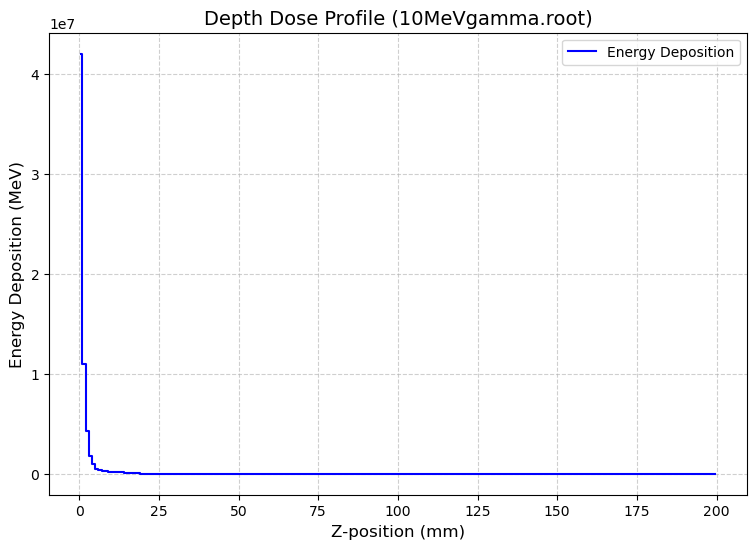

In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

def plot_depth_dose(file_path, bin_size_mm=1.0):
    # 1. Open the file and the tree 't'
    with uproot.open(file_path) as f:
        tree = f["t"]
        
        # 2. Extract and flatten the data
        # We use .ravel() to ensure it's a simple 1D array
        de = np.concatenate(tree["de"].array(library="np")).ravel()
        y = np.concatenate(tree["y"].array(library="np")).ravel()
        
        # 3. Define the Z-axis range
        # Adjust 200 to match the actual thickness of your phantom in mm
        y_min, y_max = 0, 200 
        bins = np.arange(y_min, y_max + bin_size_mm, bin_size_mm)
        
        # 4. Use weights=de to sum the energy deposited in each z-bin
        energy_sum, bin_edges = np.histogram(y, bins=bins, weights=de)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # 5. Plotting
        plt.figure(figsize=(9, 6))
        plt.plot(bin_centers, energy_sum, color='blue', drawstyle='steps-mid', label='Energy Deposition')
        
        # Formatting to match medical physics standards
        plt.xlabel('Z-position (mm)', fontsize=12)
        plt.ylabel('Energy Deposition (MeV)', fontsize=12)
        plt.title(f'Depth Dose Profile ({file_path})', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()

# Run the function
plot_depth_dose("10MeVgamma.root")